### Model adjustment process

In [12]:
import os
from transformers import BeitForImageClassification, BeitFeatureExtractor
from torch.optim import AdamW
from PIL import Image
import torch
import torch.nn as nn
from torchinfo import summary
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import accuracy_score
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np



In [11]:
# Load original model (still has 21841 classes)
raw_model_path = "/Volumes/KODAK/folder_02/Skin_cancer_Detection/model/Raw_model/beit_base_patch16_model"
model = BeitForImageClassification.from_pretrained(raw_model_path)

# Assign correct label mappings
class_labels = ['AKIEC', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'VASC']
model.config.id2label = {i: label for i, label in enumerate(class_labels)}
model.config.label2id = {label: i for i, label in enumerate(class_labels)}
model.config.num_labels = len(class_labels)  #  Ensure num_labels is set

# Resize classifier layer (IMPORTANT STEP)
model.classifier = nn.Linear(model.classifier.in_features, model.config.num_labels)

# Set to eval mode
model.eval()

# Save adjusted model
adjusted_model_path = "/Volumes/KODAK/folder_02/Skin_cancer_Detection/model/pre-prcess model/adjusted_beit_model"
os.makedirs(adjusted_model_path, exist_ok=True)
model.save_pretrained(adjusted_model_path)

# Save feature extractor
feature_extractor = BeitFeatureExtractor.from_pretrained(raw_model_path)
feature_extractor.save_pretrained(adjusted_model_path)

print(" Model successfully adjusted to 7 classes and saved.")


 Model successfully adjusted to 7 classes and saved.


In [13]:
# Ensure adjusted model have seven class


adjusted_model_path = "/Volumes/KODAK/folder_02/Skin_cancer_Detection/model/pre-prcess model/adjusted_beit_model"
model = BeitForImageClassification.from_pretrained(adjusted_model_path)

print(" Number of output classes:", model.config.num_labels)
print(" id2label mapping:", model.config.id2label)


 Number of output classes: 7
 id2label mapping: {0: 'AKIEC', 1: 'BCC', 2: 'BKL', 3: 'DF', 4: 'MEL', 5: 'NV', 6: 'VASC'}


In [21]:
# === Load adjusted model ===
model_path = "/Volumes/KODAK/folder_02/Skin_cancer_Detection/model/pre-prcess model/adjusted_beit_model"
model = BeitForImageClassification.from_pretrained(model_path)
feature_extractor = BeitFeatureExtractor.from_pretrained(model_path)

model.eval()

# === Load test image ===
test_image_path = "/Volumes/KODAK/folder_02/Skin_cancer_Detection/data/pre-process data/final_preprocess_images/nv/nv.071.jpg"  # Replace this path
image = Image.open(test_image_path).convert("RGB")

# === Preprocess image ===
inputs = feature_extractor(images=image, return_tensors="pt")

# === Inference ===
with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits
    predicted_class_idx = logits.argmax(-1).item()

# === Print result ===
predicted_label = model.config.id2label[predicted_class_idx]
print(f"🧠 Predicted class: {predicted_label}")

🧠 Predicted class: MEL


In [ ]:
# Showing model summary

# Load your adjusted model
model_path = "/Volumes/KODAK/folder_02/Skin_cancer_Detection/model/pre-prcess model/adjusted_beit_model"
model = BeitForImageClassification.from_pretrained(model_path)

# Move model to device (CPU or GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# BEiT expects input shape: (batch_size, 3, 224, 224)
input_size = (1, 3, 224, 224)  # batch_size=1 for summary

# Print model summary
summary(model, input_size=input_size, device=str(device))

Layer (type:depth-idx)                                                 Output Shape              Param #
BeitForImageClassification                                             [1, 7]                    --
├─BeitModel: 1-1                                                       [1, 768]                  --
│    └─BeitEmbeddings: 2-1                                             [1, 197, 768]             768
│    │    └─BeitPatchEmbeddings: 3-1                                   [1, 196, 768]             590,592
│    │    └─Dropout: 3-2                                               [1, 197, 768]             --
│    └─BeitEncoder: 2-2                                                [1, 197, 768]             --
│    │    └─ModuleList: 3-3                                            --                        85,169,088
│    └─Identity: 2-3                                                   [1, 197, 768]             --
│    └─BeitPooler: 2-4                                                 [1, 768]  

In [ ]:
# Model unfreezing process


# === Paths ===
adjusted_model_path = "/Volumes/KODAK/folder_02/Skin_cancer_Detection/model/pre-prcess model/adjusted_beit_model"
unfrozen_model_path = "/Volumes/KODAK/folder_02/Skin_cancer_Detection/model/pre-prcess model/unfrozen_beit_model"
os.makedirs(unfrozen_model_path, exist_ok=True)

# === Load the model ===
model = BeitForImageClassification.from_pretrained(adjusted_model_path)

# === Unfreeze all layers ===
for name, param in model.named_parameters():
    param.requires_grad = True
print("All layers have been set to trainable (requires_grad=True).")

# === Print parameter stats ===
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# === Print number of output classes ===
print(f"Number of output classes: {model.config.num_labels}")
print(f"Class label mapping (id2label): {model.config.id2label}")

# === Save unfrozen model ===
model.save_pretrained(unfrozen_model_path)

# === Save the corresponding feature extractor ===
feature_extractor = BeitFeatureExtractor.from_pretrained(adjusted_model_path)
feature_extractor.save_pretrained(unfrozen_model_path)

print(f"Unfrozen model and feature extractor saved to:\n{unfrozen_model_path}")


✅ All layers have been set to trainable (requires_grad=True).
🔢 Total parameters:     85,767,367
🧠 Trainable parameters: 85,767,367
🧾 Number of output classes: 7
📌 Class label mapping (id2label): {0: 'AKIEC', 1: 'BCC', 2: 'BKL', 3: 'DF', 4: 'MEL', 5: 'NV', 6: 'VASC'}
✅ Unfrozen model and feature extractor saved to:
/Volumes/KODAK/folder_02/Skin_cancer_Detection/model/pre-prcess model/unfrozen_beit_model


### Fine tunning model

In [11]:
# === Paths ===
data_dir = "/Volumes/KODAK/folder_02/Skin_cancer_Detection/data/pre-process data/final_Split_Images"
model_dir = "/Volumes/KODAK/folder_02/Skin_cancer_Detection/model/pre-prcess model/unfrozen_beit_model"
output_model_dir = "/Volumes/KODAK/folder_02/Skin_cancer_Detection/model/fine tuned model/final_finetuned_beit"
os.makedirs(output_model_dir, exist_ok=True)

# === Device ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"💻 Using device: {device}")

# === Feature extractor & transform ===
feature_extractor = BeitFeatureExtractor.from_pretrained(model_dir)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=feature_extractor.image_mean, std=feature_extractor.image_std)
])

# === Load datasets ===
train_dataset = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=transform)
val_dataset = datasets.ImageFolder(os.path.join(data_dir, "val"), transform=transform)
test_dataset = datasets.ImageFolder(os.path.join(data_dir, "test"), transform=transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)

# === Load model ===
model = BeitForImageClassification.from_pretrained(model_dir)
model.to(device)

# === Loss & Optimizer ===
criterion = nn.CrossEntropyLoss()
optimizer = AdamW(model.parameters(), lr=2e-5)

# === Evaluation helper ===
def evaluate(loader, model):
    model.eval()
    preds, labels = [], []
    total_loss = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(pixel_values=x)
            loss = criterion(outputs.logits, y)
            total_loss += loss.item()
            preds += outputs.logits.argmax(dim=-1).cpu().tolist()
            labels += y.cpu().tolist()
    acc = accuracy_score(labels, preds)
    return total_loss / len(loader), acc

# === Training ===
best_val_acc = 0
EPOCHS = 15

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    loop = tqdm(train_loader, desc=f"🔥 Epoch {epoch+1}/{EPOCHS}")
    for x, y in loop:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()

        outputs = model(pixel_values=x)
        loss = criterion(outputs.logits, y)
        loss.backward()
        optimizer.step()

        # === Accumulate metrics ===
        running_loss += loss.item()
        preds = outputs.logits.argmax(dim=-1)
        correct += (preds == y).sum().item()
        total += y.size(0)

        # === Live update progress bar ===
        loop.set_postfix({
            "Train Loss": f"{loss.item():.4f}",
            "Train Acc": f"{(correct / total) * 100:.2f}%"
        })

    # === Epoch summary ===
    train_loss = running_loss / len(train_loader)
    train_acc = correct / total
    val_loss, val_acc = evaluate(val_loader, model)

    print(f"\n📊 Epoch {epoch+1} Summary:")
    print(f"   🟩 Train Loss: {train_loss:.4f} | 🟢 Train Acc: {train_acc*100:.2f}%")
    print(f"   🟨 Val Loss:   {val_loss:.4f} | 🔵 Val Acc:   {val_acc*100:.2f}%")

    # Save best model
    if val_acc > best_val_acc:
        model.save_pretrained(output_model_dir)
        feature_extractor.save_pretrained(output_model_dir)
        best_val_acc = val_acc
        print(f"✅ Best model saved at epoch {epoch+1} with Val Acc: {val_acc*100:.2f}%")

# === Final test evaluation ===
test_loss, test_acc = evaluate(test_loader, model)
print(f"\n🧪 Final Test Evaluation:")
print(f"   🟥 Test Loss: {test_loss:.4f} | 🧪 Test Accuracy: {test_acc*100:.2f}%")


💻 Using device: cpu


🔥 Epoch 1/15: 100%|██████████| 765/765 [48:46<00:00,  3.83s/it, Train Loss=0.8321, Train Acc=65.65%]  



📊 Epoch 1 Summary:
   🟩 Train Loss: 0.9329 | 🟢 Train Acc: 65.65%
   🟨 Val Loss:   0.5850 | 🔵 Val Acc:   77.99%
✅ Best model saved at epoch 1 with Val Acc: 77.99%


🔥 Epoch 2/15: 100%|██████████| 765/765 [49:48<00:00,  3.91s/it, Train Loss=0.1923, Train Acc=87.64%]  



📊 Epoch 2 Summary:
   🟩 Train Loss: 0.3662 | 🟢 Train Acc: 87.64%
   🟨 Val Loss:   0.4605 | 🔵 Val Acc:   84.40%
✅ Best model saved at epoch 2 with Val Acc: 84.40%


...


📊 Epoch 13 Summary:
   🟩 Train Loss: 0.0296 | 🟢 Train Acc: 99.05%
   🟨 Val Loss:   0.6078 | 🔵 Val Acc:   87.38%


🔥 Epoch 14/15: 100%|██████████| 765/765 [39:24<00:00,  3.09s/it, Train Loss=0.0284, Train Acc=98.97%]



📊 Epoch 14 Summary:
   🟩 Train Loss: 0.0335 | 🟢 Train Acc: 98.97%
   🟨 Val Loss:   0.6497 | 🔵 Val Acc:   87.03%


🔥 Epoch 15/15: 100%|██████████| 765/765 [36:53<00:00,  2.89s/it, Train Loss=0.0026, Train Acc=98.93%]



📊 Epoch 15 Summary:
   🟩 Train Loss: 0.0318 | 🟢 Train Acc: 98.93%
   🟨 Val Loss:   0.5835 | 🔵 Val Acc:   86.84%

🧪 Final Test Evaluation:
   🟥 Test Loss: 0.5393 | 🧪 Test Accuracy: 87.38%


In [15]:
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}


In [16]:
# Save history
history["train_loss"].append(train_loss)
history["train_acc"].append(train_acc)
history["val_loss"].append(val_loss)
history["val_acc"].append(val_acc)


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# === Plot Training & Validation Accuracy/Loss Curves ===
def plot_metrics(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(14, 6))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], 'b-o', label='Train Loss')
    plt.plot(epochs, history["val_loss"], 'r-o', label='Val Loss')
    plt.title("Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], 'b-o', label='Train Acc')
    plt.plot(epochs, history["val_acc"], 'r-o', label='Val Acc')
    plt.title("Accuracy Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()


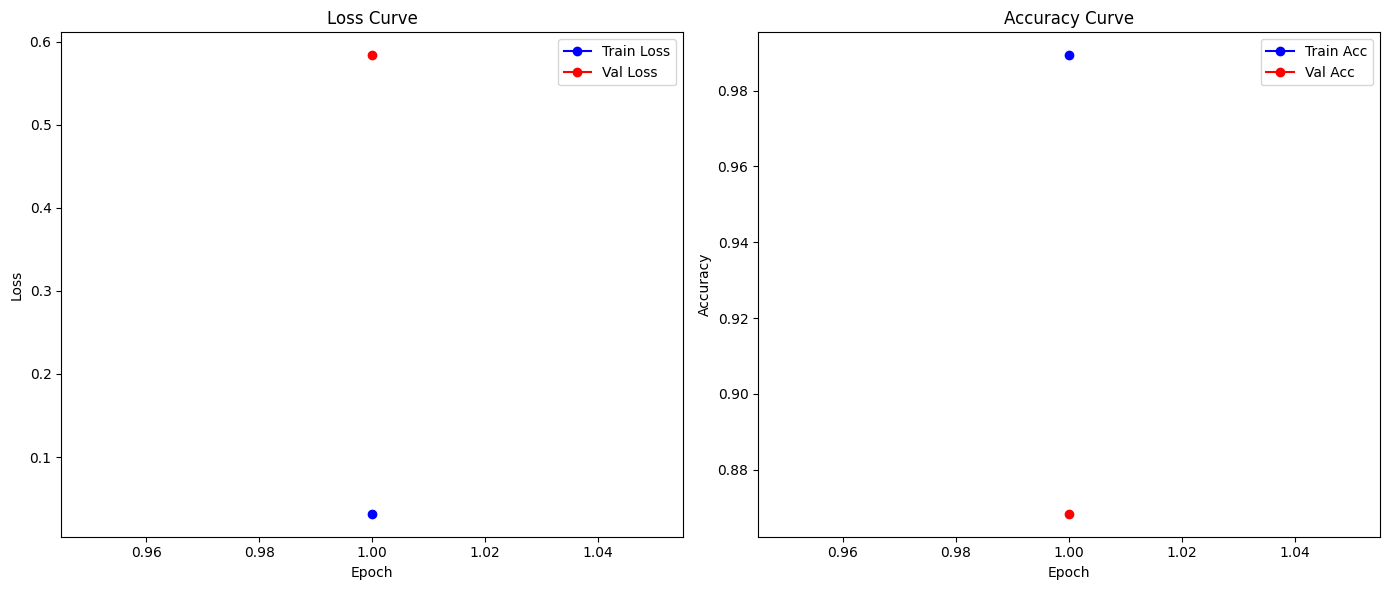

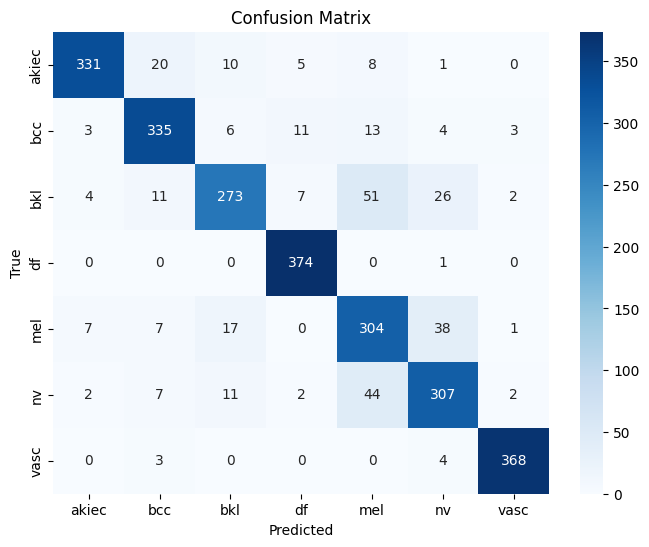

📋 Classification Report:

              precision    recall  f1-score   support

       akiec       0.95      0.88      0.92       375
         bcc       0.87      0.89      0.88       375
         bkl       0.86      0.73      0.79       374
          df       0.94      1.00      0.97       375
         mel       0.72      0.81      0.77       374
          nv       0.81      0.82      0.81       375
        vasc       0.98      0.98      0.98       375

    accuracy                           0.87      2623
   macro avg       0.88      0.87      0.87      2623
weighted avg       0.88      0.87      0.87      2623



In [18]:
# === Evaluate model on test set to get predictions ===
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        outputs = model(pixel_values=x)
        preds = outputs.logits.argmax(dim=-1).cpu().numpy()
        y_pred.extend(preds)
        y_true.extend(y.numpy())

# === Plot Confusion Matrix ===
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

# === Classification Report ===
def print_classification_report(y_true, y_pred, class_names):
    print("📋 Classification Report:\n")
    print(classification_report(y_true, y_pred, target_names=class_names))

# === Class Names ===
class_labels = train_dataset.classes  # or manually: ['AKIEC', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'VASC']

# === Call Plots ===
plot_metrics(history)
plot_confusion_matrix(y_true, y_pred, class_labels)
print_classification_report(y_true, y_pred, class_labels)


In [47]:


# === Paths ===
model_path = "/Volumes/KODAK/folder_02/Skin_cancer_Detection/model/fine tuned model/final_finetuned_beit"
image_path = "/Volumes/KODAK/folder_02/Skin_cancer_Detection/data/pre-process data/final_preprocess_images/bkl/bkl.023.jpg"  # Change to your test image

# === Device ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"💻 Inference on device: {device}")

# === Load Model and Feature Extractor ===
model = BeitForImageClassification.from_pretrained(model_path).to(device)
feature_extractor = BeitFeatureExtractor.from_pretrained(model_path)
model.eval()

# === Load and Preprocess Image ===
image = Image.open(image_path).convert("RGB")
inputs = feature_extractor(images=image, return_tensors="pt").to(device)

# === Inference ===
with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits
    predicted_class_idx = logits.argmax(-1).item()

# === Get Class Label ===
predicted_label = model.config.id2label[predicted_class_idx]
print(f"🧠 Predicted Class: {predicted_label}")


💻 Inference on device: cpu
🧠 Predicted Class: BKL


In [95]:
import torch
import cv2
import numpy as np
from PIL import Image
from torchvision import transforms
from transformers import BeitForImageClassification, BeitFeatureExtractor

# === PATHS ===
image_path = "/Users/pasindumalinda/Downloads/Mapped_Images/bcc/ISIC_0024550.jpg"  # <-- Replace this
model_path = "/Volumes/KODAK/folder_02/Skin_cancer_Detection/model/fine tuned model/final_finetuned_beit"

# === DEVICE ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"💻 Using device: {device}")

# === LOAD MODEL & FEATURE EXTRACTOR ===
model = BeitForImageClassification.from_pretrained(model_path).to(device)
model.eval()
feature_extractor = BeitFeatureExtractor.from_pretrained(model_path)

# === INDUSTRIAL PREPROCESSING FUNCTION ===
def industrial_preprocess(image_path):
    # Load image in BGR
    image = cv2.imread(image_path)

    # --- Step 1: Convert to RGB
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # --- Step 2: Apply Gaussian Blur to reduce noise
    blurred = cv2.GaussianBlur(image, (3, 3), 0)

    # --- Step 3: Apply sharpening kernel
    sharpen_kernel = np.array([[0, -1, 0],
                               [-1, 5,-1],
                               [0, -1, 0]])
    sharpened = cv2.filter2D(blurred, -1, sharpen_kernel)

    # --- Step 4: CLAHE (Contrast Limited Adaptive Histogram Equalization)
    lab = cv2.cvtColor(sharpened, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    cl = clahe.apply(l)
    merged = cv2.merge((cl, a, b))
    enhanced = cv2.cvtColor(merged, cv2.COLOR_LAB2RGB)

    # --- Step 5: Resize to model input
    resized = cv2.resize(enhanced, (224, 224))

    # --- Step 6: Convert to PIL and Normalize
    pil_image = Image.fromarray(resized)
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=feature_extractor.image_mean, std=feature_extractor.image_std)
    ])
    tensor = transform(pil_image).unsqueeze(0)
    return tensor

# === RUN INFERENCE ===
input_tensor = industrial_preprocess(image_path).to(device)

with torch.no_grad():
    outputs = model(pixel_values=input_tensor)
    logits = outputs.logits
    predicted_class = logits.argmax(dim=-1).item()
    predicted_label = model.config.id2label[predicted_class]

print(f"🧠 Predicted Skin Lesion Class: **{predicted_label}**")


💻 Using device: cpu
🧠 Predicted Skin Lesion Class: **BKL**


In [129]:
import torch
import cv2
import numpy as np
from PIL import Image
from torchvision import transforms
from transformers import BeitForImageClassification, BeitFeatureExtractor

# === PATHS ===
image_path = "/Users/pasindumalinda/Downloads/Mapped_Images/nv/ISIC_0024308.jpg"
model_path = "/Volumes/KODAK/folder_02/Skin_cancer_Detection/model/fine tuned model/final_finetuned_beit"

# === DEVICE ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"💻 Using device: {device}")

# === LOAD MODEL & FEATURE EXTRACTOR ===
model = BeitForImageClassification.from_pretrained(model_path).to(device)
model.eval()
feature_extractor = BeitFeatureExtractor.from_pretrained(model_path)

# === IMPROVED INDUSTRIAL PREPROCESSING ===
def industrial_preprocess(image_path):
    # Load image in float32 RGB
    image = cv2.imread(image_path, cv2.IMREAD_COLOR)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0

    # --- Step 1: Denoising
    image = cv2.fastNlMeansDenoisingColored((image * 255).astype(np.uint8), None, 10, 10, 7, 21).astype(np.float32) / 255.0

    # --- Step 2: CLAHE per channel (RGB)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    channels = cv2.split((image * 255).astype(np.uint8))
    clahe_channels = [clahe.apply(c) for c in channels]
    image = cv2.merge(clahe_channels).astype(np.float32) / 255.0

    # --- Step 3: Unsharp masking for sharpening
    blurred = cv2.GaussianBlur(image, (5, 5), 1)
    image = cv2.addWeighted(image, 1.5, blurred, -0.5, 0)

    # --- Step 4: Resize with anti-aliasing
    image = cv2.resize(image, (224, 224), interpolation=cv2.INTER_AREA)

    # --- Step 5: Convert to PIL and normalize using BEiT standards
    pil_image = Image.fromarray((image * 255).astype(np.uint8))
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=feature_extractor.image_mean, std=feature_extractor.image_std)
    ])
    tensor = transform(pil_image).unsqueeze(0)
    return tensor

# === RUN INFERENCE ===
input_tensor = industrial_preprocess(image_path).to(device)

with torch.no_grad():
    outputs = model(pixel_values=input_tensor)
    logits = outputs.logits
    predicted_class = logits.argmax(dim=-1).item()
    predicted_label = model.config.id2label[predicted_class]

print(f"🧠 Predicted Skin Lesion Class: **{predicted_label}**")


💻 Using device: cpu
🧠 Predicted Skin Lesion Class: **BKL**
